In [1]:
import pandas as pd
df = pd.read_csv("../data/processed/user_behavior_activity.csv")

df.head()

,auser_id,date,first_login,last_login,night_activity,file_access,usb_usage,top_urls,external_emails,risk_factor,threat_percentage
0,AAE0190,2010-01-04,8,18,0,0.0,0.0,http://kmart.com/Ode_on_Indolence/indolence/cr...,14.0,21.0,22.580645
1,AAE0190,2010-01-05,8,18,0,0.0,0.0,http://kmart.com/Ode_on_Indolence/indolence/cr...,13.0,19.5,20.967742
2,AAE0190,2010-01-06,8,18,0,0.0,0.0,http://zendesk.com/December_1964_South_Vietnam...,14.0,21.0,22.580645
3,AAE0190,2010-01-07,8,18,0,0.0,0.0,http://retailmenot.com/2012_phenomenon/aveni/j...,14.0,21.0,22.580645
4,AAE0190,2010-01-08,8,18,0,0.0,0.0,0,13.0,19.5,20.967742


In [2]:
features = df[[
    "night_activity",
    "file_access",
    "usb_usage",
    "external_emails",
    "risk_factor",
    "threat_percentage"
]]

# normalizing data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = scaler.fit_transform(features)

# Train Isolation Forest
from sklearn.ensemble import IsolationForest

model = IsolationForest(
    contamination=0.02,
    random_state=42
)

df["anomaly"] = model.fit_predict(X)

# exract suspicious users
suspicious = df[df["anomaly"] == -1]

suspicious.head()
# saving suspicious users

suspicious.to_csv(
    "../data/processed/suspicious_users.csv",
    index=False
)

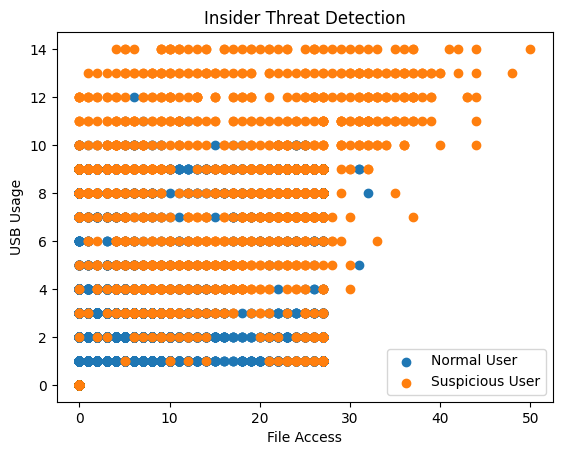

In [3]:
# visualization 
import matplotlib.pyplot as plt

normal = df[df["anomaly"] == 1]
anomaly = df[df["anomaly"] == -1]

plt.scatter(normal["file_access"], normal["usb_usage"], label="Normal User")
plt.scatter(anomaly["file_access"], anomaly["usb_usage"], label="Suspicious User")

plt.xlabel("File Access")
plt.ylabel("USB Usage")
plt.title("Insider Threat Detection")
plt.legend()

plt.show()

In [4]:
suspicious.shape

(2286, 12)

In [5]:
suspicious.sort_values("threat_percentage", ascending=False).head(10)

,auser_id,date,first_login,last_login,night_activity,file_access,usb_usage,top_urls,external_emails,risk_factor,threat_percentage,anomaly
3905,AJF0370,2010-01-29,3,23,8,37.0,14.0,0,11.0,93.0,100.000000,-1
3892,AJF0370,2010-01-13,3,23,4,50.0,14.0,0,11.0,91.5,98.387097,-1
77907,MPM0220,2010-02-01,0,23,9,39.0,12.0,0,11.0,90.0,96.774194,-1
3891,AJF0370,2010-01-12,1,22,8,36.0,13.0,0,10.0,88.0,94.623656,-1
3886,AJF0370,2010-01-06,1,22,8,32.0,13.0,http://kohls.com/Remain_in_Light/jerden/yvpraf...,11.0,87.5,94.086022,-1
3918,AJF0370,2010-02-16,3,23,6,43.0,12.0,0,11.0,86.0,92.473118,-1
77908,MPM0220,2010-02-02,1,15,7,32.0,13.0,0,11.0,85.5,91.935484,-1
3902,AJF0370,2010-01-26,3,23,8,37.0,12.0,0,10.0,85.5,91.935484,-1
77916,MPM0220,2010-02-12,0,18,5,33.0,14.0,0,11.0,85.0,91.397849,-1
77893,MPM0220,2010-01-12,2,18,6,35.0,13.0,0,11.0,85.0,91.397849,-1


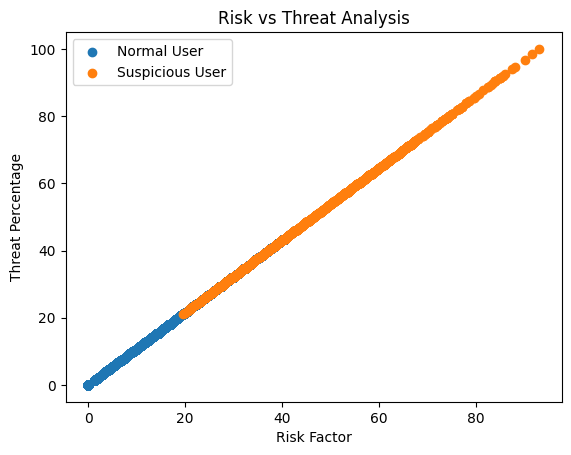

In [8]:
import matplotlib.pyplot as plt

normal = df[df["anomaly"] == 1]
anomaly = df[df["anomaly"] == -1]

plt.scatter(
    normal["risk_factor"],
    normal["threat_percentage"],
    label="Normal User"
)

plt.scatter(
    anomaly["risk_factor"],
    anomaly["threat_percentage"],
    label="Suspicious User"
)

plt.xlabel("Risk Factor")
plt.ylabel("Threat Percentage")
plt.title("Risk vs Threat Analysis")

plt.legend()
plt.show()

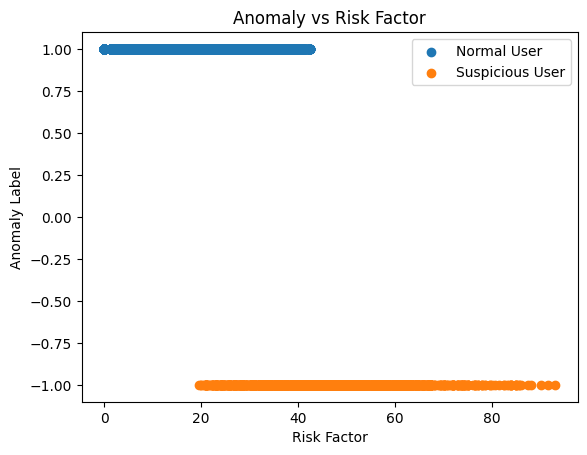

In [9]:
import matplotlib.pyplot as plt

normal = df[df["anomaly"] == 1]
anomaly = df[df["anomaly"] == -1]

plt.scatter(normal["risk_factor"], normal["anomaly"], label="Normal User")
plt.scatter(anomaly["risk_factor"], anomaly["anomaly"], label="Suspicious User")

plt.xlabel("Risk Factor")
plt.ylabel("Anomaly Label")
plt.title("Anomaly vs Risk Factor")

plt.legend()
plt.show()